In [ ]:
!pip install librosa

In [ ]:
!git clone https://github.com/karoldvl/ESC-50.git

Cloning into 'ESC-50'...
remote: Enumerating objects: 4199, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 4199 (delta 62), reused 34 (delta 34), pack-reused 4130 (from 1)
Receiving objects: 100% (4199/4199), 878.77 MiB | 27.30 MiB/s, done.
Resolving deltas: 100% (292/292), done.
Updating files: 100% (2011/2011), done.


In [ ]:
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

meta = pd.read_csv('/content/ESC-50/meta/esc50.csv')
print(meta.shape)
meta.head()

(2000, 7)


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [ ]:
print("전체 클래스 수:", meta['category'].nunique())
print("\n클래스 목록:")
print(meta['category'].unique())

전체 클래스 수: 50

클래스 목록:
['dog' 'chirping_birds' 'vacuum_cleaner' 'thunderstorm' 'door_wood_knock'
 'can_opening' 'crow' 'clapping' 'fireworks' 'chainsaw' 'airplane'
 'mouse_click' 'pouring_water' 'train' 'sheep' 'water_drops'
 'church_bells' 'clock_alarm' 'keyboard_typing' 'wind' 'footsteps' 'frog'
 'cow' 'brushing_teeth' 'car_horn' 'crackling_fire' 'helicopter'
 'drinking_sipping' 'rain' 'insects' 'laughing' 'hen' 'engine' 'breathing'
 'crying_baby' 'hand_saw' 'coughing' 'glass_breaking' 'snoring'
 'toilet_flush' 'pig' 'washing_machine' 'clock_tick' 'sneezing' 'rooster'
 'sea_waves' 'siren' 'cat' 'door_wood_creaks' 'crickets']


/tmp/ipykernel_3203/2065698822.py:11: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/2065698822.py:11: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/2065698822.py:11: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/2065698822.py:11: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/2065698822.py:11: UserWarning: Glyph 54253 (\N{HANGUL SYLLABLE POG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/2065698822.py:11: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/2065698822.py:11: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_l

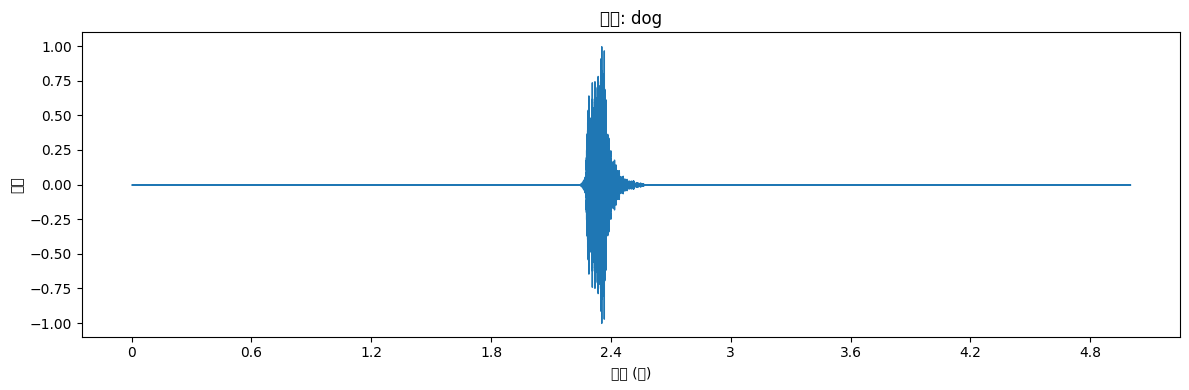

카테고리: dog
샘플링 레이트: 44100 Hz
오디오 길이: 5.00초


In [ ]:
sample = meta.iloc[0]
audio_path = f"/content/ESC-50/audio/{sample['filename']}"

y, sr = librosa.load(audio_path, sr=None)

plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title(f"파형: {sample['category']}")
plt.xlabel("시간 (초)")
plt.ylabel("진폭")
plt.tight_layout()
plt.show()

print(f"카테고리: {sample['category']}")
print(f"샘플링 레이트: {sr} Hz")
print(f"오디오 길이: {len(y)/sr:.2f}초")

## Mel Spectogram 변환

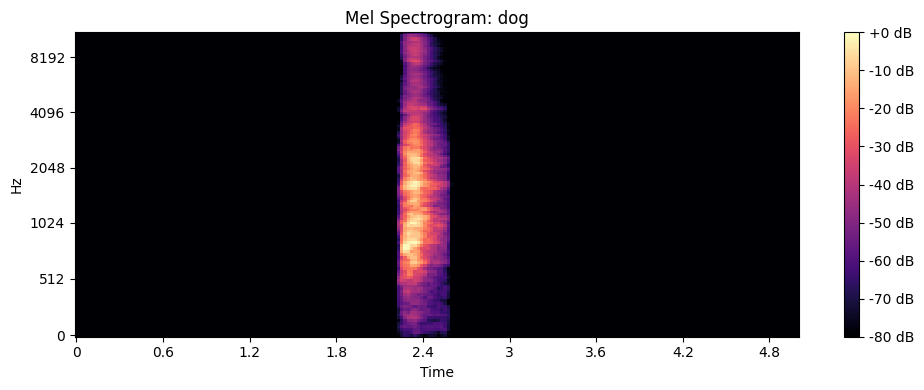

In [ ]:
y, sr = librosa.load(audio_path, sr=22050)

mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Mel Spectrogram: {sample["category"]}')
plt.tight_layout()
plt.show()

In [ ]:
def extract_mel_spectrogram(file_path, n_mels=128, max_len=128):
    """
    오디오 파일 → Mel Spectrogram 이미지(numpy array) 변환
    - n_mels: 주파수 축 해상도
    - max_len: 시간 축 길이 (고정)
    """
    y, sr = librosa.load(file_path, sr=22050, duration=5.0)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # 길이 고정 (padding or truncation)
    if mel_db.shape[1] < max_len:
        mel_db = np.pad(mel_db, ((0,0),(0, max_len - mel_db.shape[1])))
    else:
        mel_db = mel_db[:, :max_len]

    return mel_db  # shape: (128, 128)

In [ ]:
audio_dir = '/content/ESC-50/audio/'

X = []
y_labels = []

categories = sorted(meta['category'].unique())
cat_to_idx = {cat: idx for idx, cat in enumerate(categories)}

print("전처리 시작...")
for i, row in meta.iterrows():
    file_path = audio_dir + row['filename']
    mel = extract_mel_spectrogram(file_path)
    X.append(mel)
    y_labels.append(cat_to_idx[row['category']])

X = np.array(X)
y_labels = np.array(y_labels)

print(f"완료! X shape: {X.shape}, 클래스 수: {len(categories)}")

전처리 시작...
완료! X shape: (2000, 128, 128), 클래스 수: 50


In [ ]:
from sklearn.model_selection import train_test_split

X_cnn = X[:, np.newaxis, :, :]  # (2000, 1, 128, 128)

X_cnn = (X_cnn - X_cnn.mean()) / X_cnn.std()

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

print(f"학습 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")

학습 데이터: (1600, 1, 128, 128)
테스트 데이터: (400, 1, 128, 128)


## CNN 구현

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
X_train_t = torch.FloatTensor(X_train)
X_test_t  = torch.FloatTensor(X_test)
y_train_t = torch.LongTensor(y_train)
y_test_t  = torch.LongTensor(y_test)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

사용 디바이스: cpu


In [ ]:
class AudioCNN(nn.Module):
    def __init__(self, num_classes=50):
        super(AudioCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = AudioCNN(num_classes=50).to(device)
print(model)

AudioCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropou

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (output.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            total_loss += loss.item()
            correct += (output.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

# 학습 시작
EPOCHS = 30
train_losses, test_losses = [], []
train_accs, test_accs = [], []

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Loss':>9} | {'Test Acc':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    te_loss, te_acc = evaluate(model, test_loader, criterion, device)
    scheduler.step()

    train_losses.append(tr_loss)
    test_losses.append(te_loss)
    train_accs.append(tr_acc)
    test_accs.append(te_acc)

    if epoch % 5 == 0:
        print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | {te_loss:>9.4f} | {te_acc:>8.4f}")

Epoch | Train Loss | Train Acc | Test Loss | Test Acc
-------------------------------------------------------
    5 |     3.3895 |    0.1150 |    3.2334 |   0.1900
   10 |     3.0790 |    0.1669 |    2.7426 |   0.2700
   15 |     2.6978 |    0.2300 |    2.4344 |   0.3750
   20 |     2.5077 |    0.2625 |    2.3199 |   0.4025
   25 |     2.1883 |    0.3488 |    2.1036 |   0.4550
   30 |     2.0709 |    0.3638 |    2.0191 |   0.4925


/tmp/ipykernel_3203/2496667911.py:15: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/2496667911.py:15: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


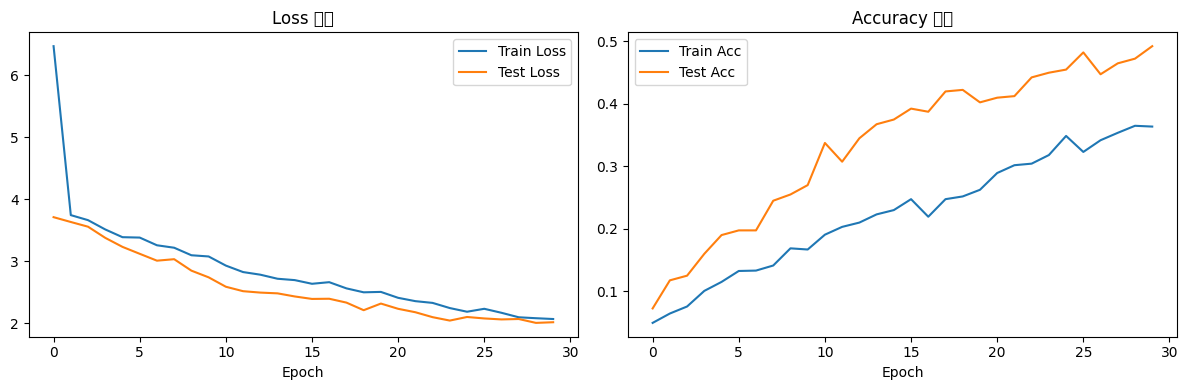


최종 테스트 정확도: 49.25%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(test_losses,  label='Test Loss')
ax1.set_title('Loss 곡선')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(train_accs, label='Train Acc')
ax2.plot(test_accs,  label='Test Acc')
ax2.set_title('Accuracy 곡선')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n최종 테스트 정확도: {test_accs[-1]*100:.2f}%")

## 성능개선 (Data augmentation 사용)

In [ ]:
def augment_audio(y, sr):
    """학습 데이터 다양화를 위한 오디오 변형"""
    choice = np.random.randint(3)

    if choice == 0:
        shift = np.random.randint(sr // 5)
        y = np.roll(y, shift)

    elif choice == 1:
        noise = np.random.randn(len(y)) * 0.005
        y = y + noise

    elif choice == 2:
        rate = np.random.uniform(0.9, 1.1)
        y = librosa.effects.time_stretch(y, rate=rate)
        if len(y) > sr * 5:
            y = y[:sr * 5]
        else:
            y = np.pad(y, (0, max(0, sr * 5 - len(y))))

    return y

In [ ]:
print("Augmentation 적용 중... (5~10분 소요)")

X_aug = []
y_aug = []

for i, row in meta.iterrows():
    file_path = audio_dir + row['filename']
    y_orig, sr = librosa.load(file_path, sr=22050, duration=5.0)

    mel_orig = extract_mel_spectrogram(file_path)
    X_aug.append(mel_orig)
    y_aug.append(cat_to_idx[row['category']])

    y_transformed = augment_audio(y_orig, sr)
    mel_aug = librosa.feature.melspectrogram(y=y_transformed, sr=sr, n_mels=128)
    mel_aug_db = librosa.power_to_db(mel_aug, ref=np.max)
    if mel_aug_db.shape[1] < 128:
        mel_aug_db = np.pad(mel_aug_db, ((0,0),(0, 128 - mel_aug_db.shape[1])))
    else:
        mel_aug_db = mel_aug_db[:, :128]

    X_aug.append(mel_aug_db)
    y_aug.append(cat_to_idx[row['category']])

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)
print(f"완료! 원본 2000개 → Augmented {len(X_aug)}개")

Augmentation 적용 중... (5~10분 소요)
완료! 원본 2000개 → Augmented 4000개


In [ ]:
X_aug_cnn = X_aug[:, np.newaxis, :, :]
X_aug_cnn = (X_aug_cnn - X_aug_cnn.mean()) / X_aug_cnn.std()

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_aug_cnn, y_aug, test_size=0.2, random_state=42, stratify=y_aug
)

train_loader2 = DataLoader(
    TensorDataset(torch.FloatTensor(X_train2), torch.LongTensor(y_train2)),
    batch_size=32, shuffle=True
)
test_loader2 = DataLoader(
    TensorDataset(torch.FloatTensor(X_test2), torch.LongTensor(y_test2)),
    batch_size=32, shuffle=False
)

model2 = AudioCNN(num_classes=50).to(device)
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)
scheduler2 = optim.lr_scheduler.StepLR(optimizer2, step_size=10, gamma=0.5)

train_accs2, test_accs2 = [], []

for epoch in range(1, 31):
    tr_loss, tr_acc = train_epoch(model2, train_loader2, optimizer2, criterion, device)
    te_loss, te_acc = evaluate(model2, test_loader2, criterion, device)
    scheduler2.step()
    train_accs2.append(tr_acc)
    test_accs2.append(te_acc)
    if epoch % 5 == 0:
        print(f"Epoch {epoch} | Train: {tr_acc:.4f} | Test: {te_acc:.4f}")

Epoch 5 | Train: 0.1237 | Test: 0.2137
Epoch 10 | Train: 0.1819 | Test: 0.3125
Epoch 15 | Train: 0.2381 | Test: 0.4775
Epoch 20 | Train: 0.2694 | Test: 0.5200
Epoch 25 | Train: 0.3391 | Test: 0.5825
Epoch 30 | Train: 0.3691 | Test: 0.6112


/tmp/ipykernel_3203/14695610.py:8: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/14695610.py:8: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/14695610.py:8: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/14695610.py:8: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/14695610.py:8: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/14695610.py:8: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/14695610.py:8: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykern

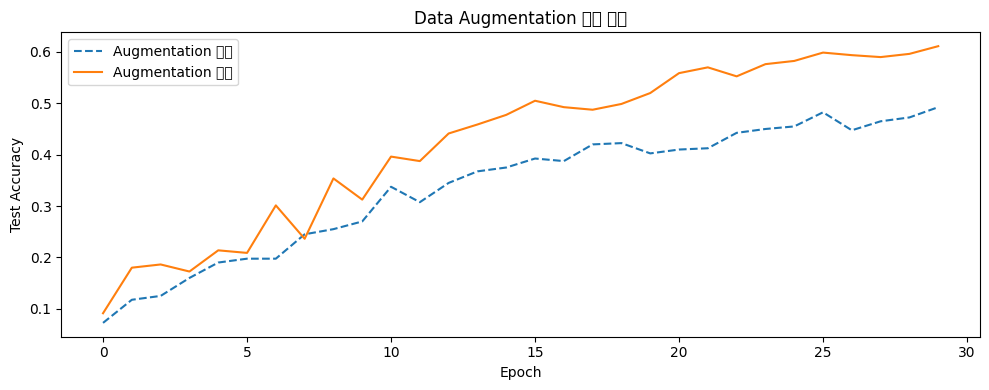

기존 정확도:   49.25%
개선 후 정확도: 61.12%


In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(test_accs,  label='Augmentation 없음', linestyle='--')
plt.plot(test_accs2, label='Augmentation 적용')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.title('Data Augmentation 효과 비교')
plt.legend()
plt.tight_layout()
plt.show()

print(f"기존 정확도:   {test_accs[-1]*100:.2f}%")
print(f"개선 후 정확도: {test_accs2[-1]*100:.2f}%")

/tmp/ipykernel_3203/3762549042.py:27: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/3762549042.py:27: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/3762549042.py:27: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/3762549042.py:27: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/3762549042.py:27: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/3762549042.py:27: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/3762549042.py:27: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_l

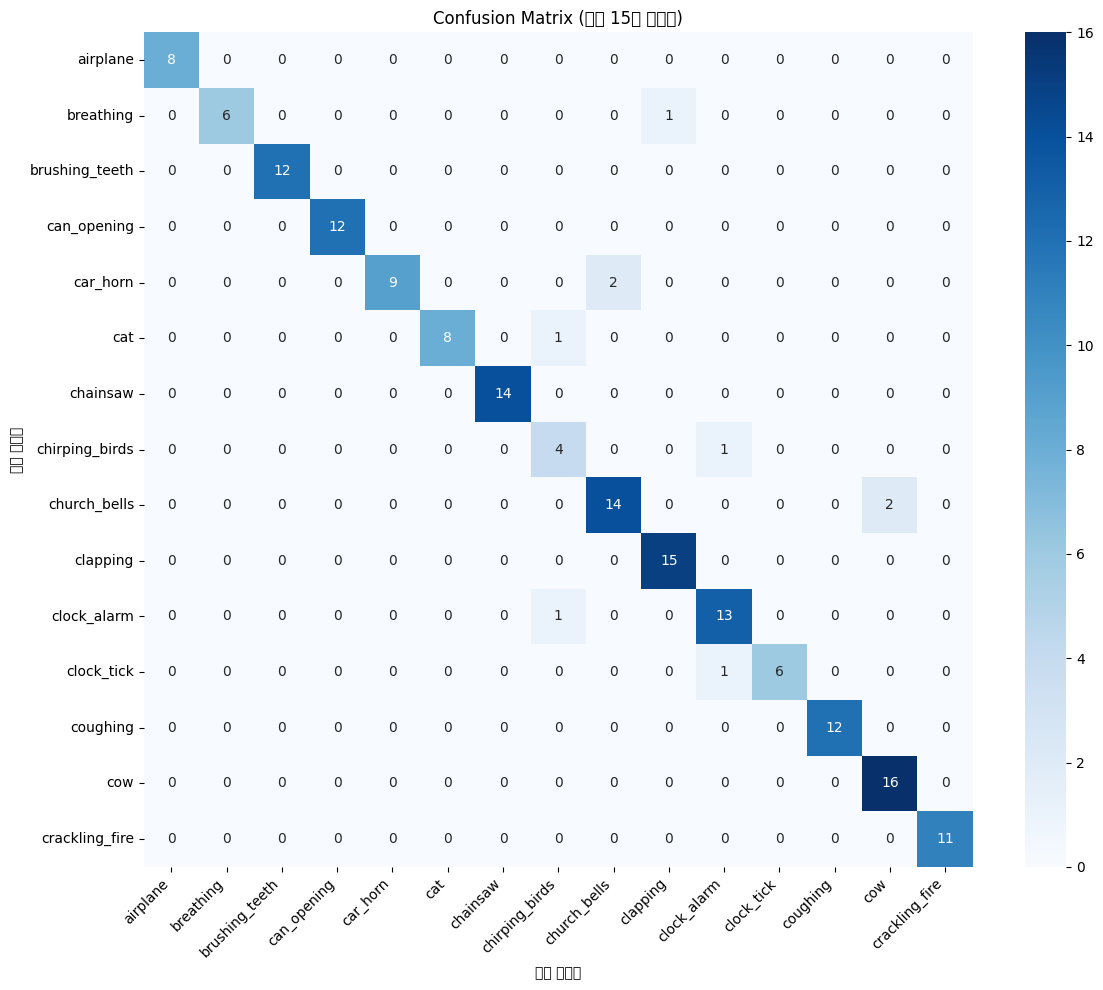


클래스별 분류 성능:
                  precision    recall  f1-score   support

        airplane      0.400     0.500     0.444        16
       breathing      1.000     0.375     0.545        16
  brushing_teeth      0.857     0.750     0.800        16
     can_opening      0.706     0.750     0.727        16
        car_horn      0.818     0.562     0.667        16
             cat      0.800     0.500     0.615        16
        chainsaw      0.824     0.875     0.848        16
  chirping_birds      0.400     0.250     0.308        16
    church_bells      0.538     0.875     0.667        16
        clapping      0.789     0.938     0.857        16
     clock_alarm      0.765     0.812     0.788        16
      clock_tick      1.000     0.375     0.545        16
        coughing      0.706     0.750     0.727        16
             cow      0.615     1.000     0.762        16
  crackling_fire      0.786     0.688     0.733        16
        crickets      0.542     0.812     0.650        16


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model2.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader2:
        X_batch = X_batch.to(device)
        output = model2(X_batch)
        preds = output.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

top_classes = 15
cm = confusion_matrix(all_labels, all_preds)
cm_top = cm[:top_classes, :top_classes]
label_names = categories[:top_classes]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_top, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix (상위 15개 클래스)')
plt.ylabel('실제 클래스')
plt.xlabel('예측 클래스')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n클래스별 분류 성능:")
print(classification_report(all_labels, all_preds,
      target_names=categories, digits=3))

/tmp/ipykernel_3203/920987686.py:17: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/920987686.py:17: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/920987686.py:18: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/results/learning_curve.png', dpi=150)
/tmp/ipykernel_3203/920987686.py:18: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/results/learning_curve.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) 

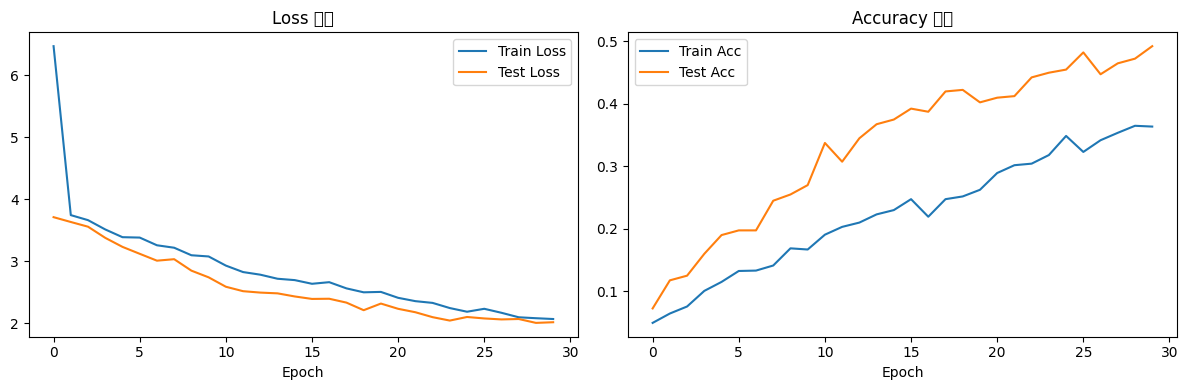

학습 곡선 저장 완료!


In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs('/content/results', exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='Train Loss')
ax1.plot(test_losses, label='Test Loss')
ax1.set_title('Loss 곡선')
ax1.set_xlabel('Epoch')
ax1.legend()
ax2.plot(train_accs, label='Train Acc')
ax2.plot(test_accs, label='Test Acc')
ax2.set_title('Accuracy 곡선')
ax2.set_xlabel('Epoch')
ax2.legend()
plt.tight_layout()
plt.savefig('/content/results/learning_curve.png', dpi=150)
plt.show()
print("학습 곡선 저장 완료!")

/tmp/ipykernel_3203/2015490842.py:25: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/2015490842.py:25: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/2015490842.py:25: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/2015490842.py:25: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3203/2015490842.py:26: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/results/confusion_matrix.png', dpi=150)
/tmp/ipykernel_3203/2015490842.py:26: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/results/confusion_matrix.png', dpi=150)
/tmp/ipykernel_3203/2015490842.py:26: UserWarning: G

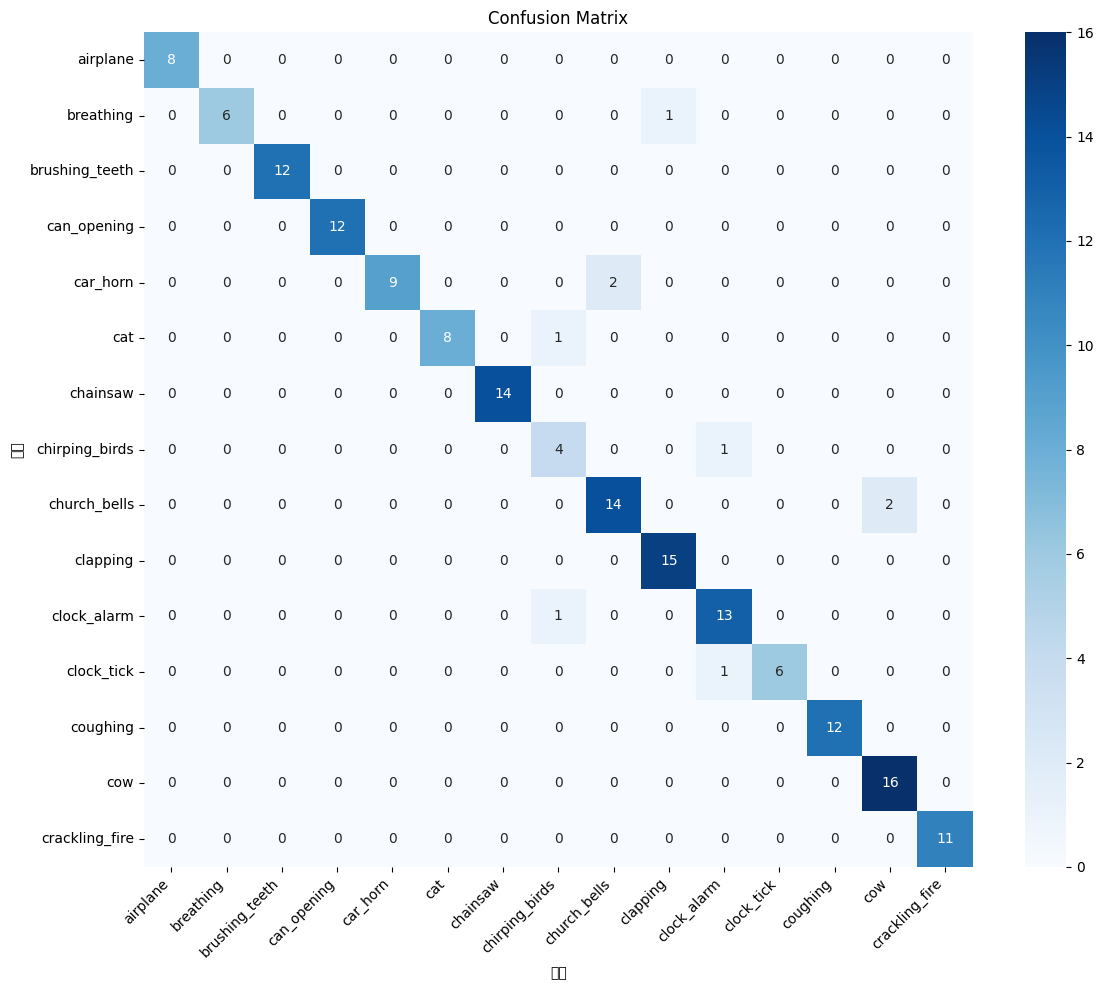

Confusion Matrix 저장 완료!


In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

model2.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader2:
        X_batch = X_batch.to(device)
        output = model2(X_batch)
        all_preds.extend(output.argmax(1).cpu().numpy())
        all_labels.extend(y_batch.numpy())

top_n = 15
cm = confusion_matrix(all_labels, all_preds)
cm_top = cm[:top_n, :top_n]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_top, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories[:top_n],
            yticklabels=categories[:top_n])
plt.title('Confusion Matrix')
plt.ylabel('실제')
plt.xlabel('예측')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/results/confusion_matrix.png', dpi=150)
plt.show()
print("Confusion Matrix 저장 완료!")

In [ ]:
import os, shutil

base = '/content/esc50-audio-classification'

os.makedirs(f'{base}/results', exist_ok=True)
os.makedirs(f'{base}/notebooks', exist_ok=True)
os.makedirs(f'{base}/src', exist_ok=True)

shutil.copy('/content/results/learning_curve.png',   f'{base}/results/')
shutil.copy('/content/results/confusion_matrix.png', f'{base}/results/')

print("폴더 구조:")
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files:
        print(f'{indent}  {f}')

폴더 구조:
esc50-audio-classification/
  notebooks/
  results/
    learning_curve.png
    confusion_matrix.png
  src/
